# ForestWatch Papua — Training **MODEL: Attention U-Net (SCSE)**

**Jalankan di KOMPUTER 1.** Arsitektur: `unet_scse` + `resnet50` (ImageNet). Resep training (loss, class weights, weighted sampler, AMP, freeze-encoder warmup, cosine LR) **identik** dengan ke-2 model lain → perbandingan apple-to-apple.

Output ditulis ke **folder khusus model ini** di gdrive: `ForestWatch_Outputs/Model_Comparison/model_1_attention_unet/` (checkpoint, kurva, metrics, confusion, ONNX, summary) → 3 mesin paralel **tidak saling timpa**.

Setelah ke-3 model selesai, jalankan `compare_and_select_best_model.ipynb`.

## Bagian 0 — Setup environment (Colab **/** Lab **/** Jetson)

Notebook ini **berdiri sendiri**. Ia **memuat hasil EDA & preprocessing**
(Bagian 1–14 dari `forestwatch_papua_full_pipeline.ipynb`) yang sudah tersimpan
di Google Drive — **tidak menghitung ulang**.

- **Google Colab** → set `ENV = "colab"`. Sel setup meng-clone repo, install
  package, lalu mount Drive. (Dipakai hanya untuk bundling `.tar` ke Drive.)
- **Komputer lab** → set `ENV = "lab"`. Prasyarat **sekali saja**:
  1. Install **Google Drive for Desktop**, login akun yang sama, set folder
     `Satria Data 3.0` ke mode **Mirror** (bukan *Stream-only*) supaya file `.npz`
     benar-benar ada di disk lokal (DataLoader membaca ribuan file tiap epoch).
  2. Di clone repo lokal jalankan: `pip install -e ".[ml]"`.
  3. Sesuaikan `DRIVE_ROOT` ke path mount Drive Desktop (mis. `G:/My Drive/Satria Data 3.0`).
- **Jetson Orin** (JetPack 5.x, Python 3.8, torch 2.1) → set `ENV = "jetson"`.
  Arsitektur **PC = storage, Jetson = compute** (dataset di-mount via SMB).
  Prasyarat **sekali saja**:
  1. Di PC: share folder hasil ekstrak `Bahan_Training_Model/` (berisi `train/`,
     `val/`, `test/`, `class_weights.json`, `patch_sampler_weights_shared.json`)
     via SMB. Di Jetson mount, mis.:
     `sudo mount -t cifs //IP_PC/Dataset_Satria /mnt/forestwatch_dataset -o user=USER,uid=$(id -u),gid=$(id -g)`.
  2. Pastikan torch JetPack ada (**JANGAN** reinstall via pip):
     `python -c "import torch; print(torch.__version__, torch.cuda.is_available())"` → `2.1.x True`.
  3. Di clone repo lokal jalankan: `pip install -e ".[jetson]"` (deps ML non-torch).
  4. Sesuaikan `DATA_ROOT` ke path mount SMB (mis. `/mnt/forestwatch_dataset`).

In [ ]:
# === Bagian 0 — Setup (set ENV = "colab" / "lab" / "jetson") ===
ENV = "lab"   # "colab" (Google Colab) | "lab" (PC + Drive Desktop) | "jetson" (Jetson Orin + SMB)
from pathlib import Path

DRIVE_ROOT = None     # diisi utk colab/lab
DATA_ROOT = None      # diisi utk jetson (mount SMB dari PC)
OUTPUTS_ROOT = None   # diisi utk jetson (output ke disk lokal Jetson)

if ENV == "colab":
    import subprocess, sys, importlib
    # clone pertama kali / pull sesi berikutnya (selalu kode terbaru), lalu install.
    subprocess.run(
        "cd /content && (git -C fw_repo pull -q || git clone --depth 1 "
        "https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo)",
        shell=True, check=False,
    )
    subprocess.run("pip install -q -e /content/fw_repo[gee,gis,ml]", shell=True, check=False)
    if "/content/fw_repo/src" not in sys.path:
        sys.path.insert(0, "/content/fw_repo/src")
    for _m in [m for m in list(sys.modules) if m == "forestwatch" or m.startswith("forestwatch.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/Satria Data 3.0")
    assert DRIVE_ROOT.exists(), f"DRIVE_ROOT {DRIVE_ROOT} tidak ada — cek mount Drive."
elif ENV == "lab":
    DRIVE_ROOT = Path(r"G:/My Drive/Satria Data 3.0")   # <- SESUAIKAN path mount Drive Desktop lab
    assert DRIVE_ROOT.exists(), (
        f"DRIVE_ROOT {DRIVE_ROOT} tidak ada — cek mount Drive / sync (mode Mirror)."
    )
elif ENV == "jetson":
    # JetPack 5.x / Python 3.8 / torch 2.1 (dari JetPack -- JANGAN reinstall torch via pip).
    # Dataset hasil ekstrak di-mount via SMB dari PC (cifs). EDIT path mount di bawah.
    DATA_ROOT = Path("/mnt/forestwatch_dataset")        # <- folder 'Bahan_Training_Model' yg di-mount (train/val/test + json)
    OUTPUTS_ROOT = Path.home() / "forestwatch_outputs"  # output lokal Jetson (cepat); salin ke PC utk notebook banding
    assert DATA_ROOT.exists(), (
        f"DATA_ROOT {DATA_ROOT} tidak ada — mount SMB share dari PC dulu (mount -t cifs ...)."
    )
else:
    raise ValueError("ENV harus 'colab', 'lab', atau 'jetson'")

import torch
_root = DATA_ROOT if ENV == "jetson" else DRIVE_ROOT
_gpu = f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""
print(f"ENV={ENV} | ROOT={_root} | CUDA={torch.cuda.is_available()}{_gpu}")

In [ ]:
# === Deklarasi path (hasil EDA & preprocessing) + load config ===
from forestwatch.config import load_config
from forestwatch.utils.io import save_json, load_json
cfg = load_config()

if ENV == "jetson":
    # Jetson: tak ada Drive. Data dari mount SMB (cell 4); output ke disk lokal Jetson.
    OUT_DIR     = OUTPUTS_ROOT
    MASK_DIR    = OUTPUTS_ROOT / 'ForestWatch_Masks'
    MODELS_ROOT = OUTPUTS_ROOT / 'Model_Comparison'
else:
    TILES_T1   = DRIVE_ROOT / 'ForestWatch_Tiles_T1'
    TILES_T2   = DRIVE_ROOT / 'ForestWatch_Tiles_T2'
    PATCH_DIR  = DRIVE_ROOT / 'ForestWatch_Patches'           # patch Papua (+ ckpt kanonik)
    PATCHES_TRANSFER  = DRIVE_ROOT / 'ForestWatch_Patches_Transfer'
    AUGMENTED_PATCHES = DRIVE_ROOT / 'Augmented_Patches'
    DIST_DIR   = DRIVE_ROOT / 'Distribution_Reports'
    MASK_DIR   = DRIVE_ROOT / 'ForestWatch_Masks'
    OUT_DIR    = DRIVE_ROOT / 'ForestWatch_Outputs'
    MODELS_ROOT = OUT_DIR / 'Model_Comparison'                # folder induk 3 model

MODELS_ROOT.mkdir(parents=True, exist_ok=True)
print('Resep training :', cfg['training']['loss']['type'],
      '| epochs:', cfg['training']['epochs'], '| batch:', cfg['training']['batch_size'])
print('MODELS_ROOT    :', MODELS_ROOT)

In [ ]:
# === Muat hasil PREPROCESSING (deklarasi + panggil; BUKAN hitung ulang) ===
import json
from forestwatch.constants import N_CLASSES, CLASS_NAMES
from forestwatch.data import build_dataloaders_from_files, list_patches, split_files
from forestwatch.training.metrics import median_frequency_weights

if ENV == "jetson":
    # Dataset SUDAH diekstrak di PC (train/val/test + class_weights.json) & di-mount SMB.
    # Tak perlu split ulang (sudah materialized jadi folder) atau akses Drive.
    BAHAN_DIR = DATA_ROOT
    final_train_files = list_patches(BAHAN_DIR / 'train')
    val_p  = list_patches(BAHAN_DIR / 'val')
    test_p = list_patches(BAHAN_DIR / 'test')
    assert final_train_files and val_p and test_p, (
        f"train/val/test kosong di {BAHAN_DIR} — cek mount SMB & hasil ekstraksi di PC."
    )
    class_weights = load_json(BAHAN_DIR / 'class_weights.json')['class_weights']
    print(f"[jetson] train={len(final_train_files)} val={len(val_p)} test={len(test_p)} <- {BAHAN_DIR}")
    print('class_weights (dari PC):', [round(float(w), 3) for w in class_weights])
else:
    # Split sumber-aware IDENTIK Bagian 14.1 (seed=42): val/test = Papua-only holdout;
    # transfer + augmentasi offline -> train. Class weights dari distribusi Bagian 14.3.
    papua_files    = list_patches(PATCH_DIR)
    transfer_files = list_patches(PATCHES_TRANSFER)
    aug_files      = list_patches(AUGMENTED_PATCHES)
    assert papua_files, (
        f"Tidak ada patch di {PATCH_DIR}. Pastikan Bagian 1-14 (notebook utama) sudah "
        "dijalankan & Google Drive sudah selesai sync."
    )

    train_p, val_p, test_p = split_files(papua_files, train_ratio=0.8, val_ratio=0.1, seed=42)
    final_train_files = list(train_p) + list(transfer_files) + list(aug_files)
    print(f"train={len(final_train_files)} (papua={len(train_p)}+transfer={len(transfer_files)}"
          f"+aug={len(aug_files)}), val={len(val_p)}, test={len(test_p)} (Papua holdout)")

    _post_aug = DIST_DIR / 'distribution_post_augmentation_on_target.json'
    assert _post_aug.exists(), (
        f"{_post_aug} belum ada — jalankan Bagian 14.3 di notebook utama dulu "
        "(recompute distribusi TRAIN FINAL + median-frequency weights)."
    )
    dist_final = {int(k): int(v) for k, v in json.load(open(_post_aug))['counts'].items()}
    class_weights = median_frequency_weights(dist_final, n_classes=N_CLASSES)
    print('class_weights (median-freq):', [round(float(w), 3) for w in class_weights])

In [ ]:
# === Siapkan artefak training: jetson (pakai mount) / colab+lab (bundling .tar ke Drive) ===
if ENV == "jetson":
    # Data sudah diekstrak & di-mount SMB; sampler cache sudah dihitung di Colab/PC. Tak ada
    # bundling/ekstraksi di sini. (final_train_files/val_p/test_p sudah dari cell 4.)
    SAMPLER_CACHE = BAHAN_DIR / 'patch_sampler_weights_shared.json'
    assert SAMPLER_CACHE.exists(), (
        f"{SAMPLER_CACHE} belum ada — hitung dulu di Colab/PC (compute_patch_sampler_weights), "
        "lalu sertakan di share SMB."
    )
    print(f"[jetson] pakai {SAMPLER_CACHE.name} dari mount SMB (tanpa bundling/ekstraksi).")
else:
    # Bundling .tar (anti-bottleneck I/O FUSE/rclone) -> simpan ke Bahan_Training_Model.
    # Sekali dibuat (SHARED lintas 3 notebook model + notebook banding, idempoten -> notebook
    # lain tinggal skip -- create_dataset_archives melewati part yang sudah final).
    from forestwatch.data.dataset import compute_patch_sampler_weights, create_dataset_archives

    BAHAN_DIR = DRIVE_ROOT / 'Bahan_Training_Model'

    def _items(files, root, prefix):
        return [(f"{prefix}/{Path(f).relative_to(Path(root)).as_posix()}", f) for f in files]

    train_items = (_items(train_p, PATCH_DIR, 'papua')
                   + _items(transfer_files, PATCHES_TRANSFER, 'transfer')
                   + _items(aug_files, AUGMENTED_PATCHES, 'aug'))
    splits = {
        'train': train_items,
        'val': _items(val_p, PATCH_DIR, 'papua'),
        'test': _items(test_p, PATCH_DIR, 'papua'),
    }
    create_dataset_archives(splits, BAHAN_DIR, n_train_parts=7, max_workers=64)

    # class_weights.json: artefak ringan (IDENTIK untuk 3 model), murah disimpan tanpa
    # perlu ekstraksi -- tinggal dipindah ke mesin training (PC/Jetson) bersama .tar.
    save_json({'class_weights': [float(w) for w in class_weights]}, BAHAN_DIR / 'class_weights.json')
    print(f"[Bahan_Training_Model] .tar (train/val/test) + class_weights.json siap di {BAHAN_DIR}")

    # patch_sampler_weights_shared.json: SHARED lintas 3 model + PC + Jetson. Cek dulu di
    # Bahan_Training_Model -- kalau SUDAH ADA (mis. dihitung notebook model pertama / mesin
    # lain), pakai langsung (tak baca ulang ~173k label patch). Kalau BELUM, hitung sekarang
    # secara paralel (64 worker) langsung dari sumber Drive -- berlaku utk Colab JUGA, supaya
    # PC/Jetson berikutnya tinggal pakai cache ini tanpa ekstrak+hitung ulang. Key cache =
    # "/".join(parts[-3:]) dari path HASIL EKSTRAK ("papua/tile_xxx/p*.npz" / "<kelas>/
    # tile_xxx/p*.npz") -- disamakan via `keys=` dari arcname (prefix 'train/') agar cocok
    # dengan key yang nanti diturunkan PC/Jetson dari path lokal hasil extract_dataset_archives.
    SAMPLER_CACHE = BAHAN_DIR / 'patch_sampler_weights_shared.json'
    sampler_files = [src for _, src in train_items]
    sampler_keys = ["/".join((Path("train") / arcname).parts[-3:]) for arcname, _ in train_items]
    if SAMPLER_CACHE.exists():
        print(f"[{ENV}] {SAMPLER_CACHE.name} sudah ada di {BAHAN_DIR} -- pakai langsung (skip hitung ulang).")
    else:
        compute_patch_sampler_weights(
            sampler_files, class_weights, cache_path=SAMPLER_CACHE, keys=sampler_keys,
        )
        print(f"[{ENV}] {SAMPLER_CACHE.name} dihitung & disimpan di {BAHAN_DIR}")

    if ENV == 'colab':
        print("[Colab] Lewati ekstraksi lokal (disk ~73GB < dataset terekstrak ~97GB) -- "
              "extract_dataset_archives dilakukan di mesin training (PC, disk lokal cukup).")
    else:
        from forestwatch.data.dataset import extract_dataset_archives

        LOCAL_DATA_DIR = Path.home() / 'dataset_local'
        local_dirs = extract_dataset_archives(BAHAN_DIR, LOCAL_DATA_DIR, max_workers=64)

        final_train_files = list_patches(local_dirs['train'])
        val_p = list_patches(local_dirs['val'])
        test_p = list_patches(local_dirs['test'])
        print(f"[lokal] train={len(final_train_files)} val={len(val_p)} test={len(test_p)} -> {LOCAL_DATA_DIR}")


Counting pixels:   0%|          | 0/173078 [00:00<?, ?it/s]

Counting pixels:   0%|          | 0/19345 [00:00<?, ?it/s]

Counting pixels:   0%|          | 0/19346 [00:00<?, ?it/s]

Proporsi piksel per kelas -- Train FINAL (papua+transfer+aug) vs Val/Test holdout:

  Kelas            Train FINAL (173078p)          Val (19345p)         Test (19346p)
  Perairan         60.5% (6,857,785,545)   66.8% (847,041,017)   66.7% (845,208,695)
  Hutan            32.7% (3,714,769,070)   31.6% (401,087,562)   31.7% (401,926,274)
  Lahan Terbuka       1.2% (138,579,237)     0.5% ( 5,831,617)     0.5% ( 6,240,495)
  Sawit               1.1% (126,185,654)     0.3% ( 3,781,782)     0.4% ( 4,577,027)
  Pertanian Lain      2.6% (297,497,904)     0.7% ( 8,777,644)     0.7% ( 8,631,392)
  Tambang              0.7% (82,216,580)     0.0% (    35,618)     0.0% (    53,367)
  Permukiman          1.1% (125,805,818)     0.1% ( 1,238,680)     0.1% ( 1,222,206)
  TOTAL piksel            11,342,839,808         1,267,793,920         1,267,859,456


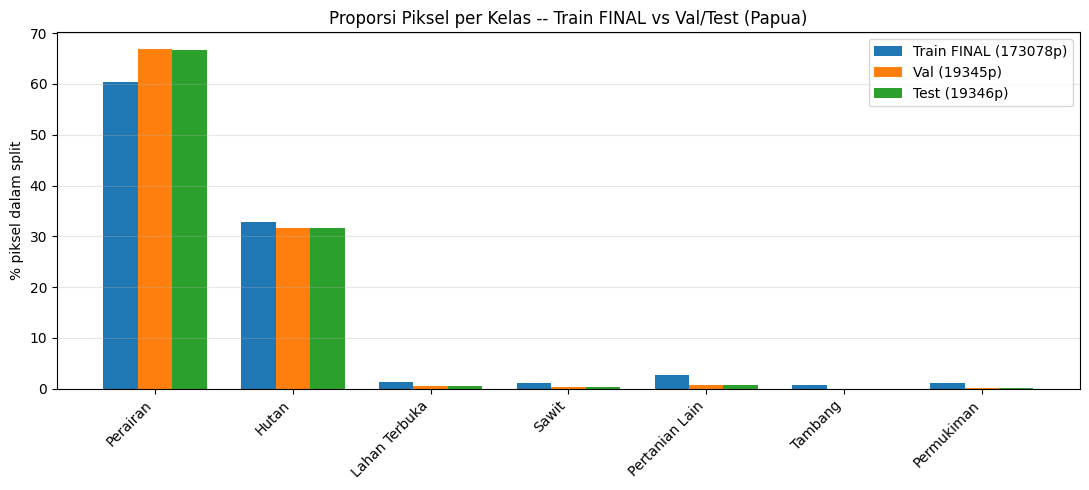

In [ ]:
# === EDA cepat: distribusi piksel -- TRAIN FINAL (papua+transfer+aug) vs Val/Test holdout ===
# Sanity-check sebelum training: TRAIN di sini = final_train_files (train_p + transfer_files
# + aug_files), yaitu data yg BENAR-BENAR dipakai model (sudah termasuk augmentasi offline
# utk kelas minor). Val/Test = Papua-only holdout (val_p/test_p), tanpa augmentasi.
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm


def _count_pixels(files, max_workers=64):
    counts = {c: 0 for c in range(N_CLASSES)}
    if not files:
        return counts

    def _read_lab(f):
        return np.load(f)['lab']

    with ThreadPoolExecutor(max_workers=max_workers) as exe:
        for lab in tqdm(exe.map(_read_lab, files), total=len(files), desc='Counting pixels'):
            u, cnt = np.unique(lab, return_counts=True)
            for cls, n in zip(u.tolist(), cnt.tolist()):
                if 0 <= int(cls) < N_CLASSES:
                    counts[int(cls)] += int(n)
    return counts


split_dist = {
    f'Train FINAL ({len(final_train_files)}p)': _count_pixels(final_train_files),
    f'Val ({len(val_p)}p)': _count_pixels(val_p),
    f'Test ({len(test_p)}p)': _count_pixels(test_p),
}

print('Proporsi piksel per kelas -- Train FINAL (papua+transfer+aug) vs Val/Test holdout:\n')
print(f"  {'Kelas':<16}" + ''.join(f'{name:>22}' for name in split_dist))
for c in range(N_CLASSES):
    row = f"  {CLASS_NAMES[c]:<16}"
    for d in split_dist.values():
        total = sum(d.values()) or 1
        row += f'{100 * d[c] / total:5.1f}% ({d[c]:>10,})'.rjust(22)
    print(row)
print(f"  {'TOTAL piksel':<16}" + ''.join(f'{sum(d.values()):>22,}' for d in split_dist.values()))

# Grafik proporsi per-kelas per-split
import matplotlib.pyplot as plt
x = np.arange(N_CLASSES)
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, d) in enumerate(split_dist.items()):
    total = sum(d.values()) or 1
    pct = [100 * d[c] / total for c in range(N_CLASSES)]
    ax.bar(x + (i - 1) * width, pct, width, label=name)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('% piksel dalam split'); ax.set_title('Proporsi Piksel per Kelas -- Train FINAL vs Val/Test (Papua)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

In [4]:
# === Worker tuning (dinamis: optimal di lab multi-core, minimal 4 di Colab) ===
import os
N_WORKERS = max(4, min(8, (os.cpu_count() or 2) - 1))
print(f"os.cpu_count()={os.cpu_count()} -> num_workers={N_WORKERS}; "
      "persistent_workers=True, pin_memory=True (di-set saat build DataLoader).")

os.cpu_count()=2 -> num_workers=4; persistent_workers=True, pin_memory=True (di-set saat build DataLoader).


## Bagian 15 — Build Model + Training (Attention U-Net (SCSE))

In [5]:
# === Identitas model (HANYA cell ini yang beda antar-3 notebook training) ===
MODEL_KEY  = "model_1_attention_unet"
MODEL_ARCH = dict(architecture="unet_scse", encoder_name="resnet50")
MODEL_DIR  = MODELS_ROOT / MODEL_KEY
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH  = MODEL_DIR / 'best_model.pt'      # per-model -> tak bentrok antar mesin
print('MODEL_KEY :', MODEL_KEY, '|', MODEL_ARCH)
print('MODEL_DIR :', MODEL_DIR)

MODEL_KEY : model_1_attention_unet | {'architecture': 'unet_scse', 'encoder_name': 'resnet50'}
MODEL_DIR : /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet


In [ ]:
# === Build DataLoaders + model + loss ===
from forestwatch.model.architecture import build_unet, count_parameters
from forestwatch.model.losses import make_loss_fn

use_sampler = cfg['training'].get('use_weighted_sampler', True)
train_loader, val_loader, test_loader = build_dataloaders_from_files(
    final_train_files, val_p, test_p,
    batch_size=cfg['training']['batch_size'],
    num_workers=N_WORKERS,
    augment_p=cfg['training']['augmentation'],
    class_weights=class_weights if use_sampler else None,
    sampler_cache=SAMPLER_CACHE,  # = BAHAN_DIR/patch_sampler_weights_shared.json (cell bundling)
    sampler_keys=sampler_keys if ENV == "colab" else None,
    persistent_workers=True,
)
print(f"Train {len(train_loader.dataset)} | Val {len(val_loader.dataset)} | Test {len(test_loader.dataset)}")

model = build_unet(
    in_channels=cfg['model']['in_channels'], classes=cfg['model']['classes'],
    encoder_weights=cfg['model']['encoder_weights'], **MODEL_ARCH,
)
print(f"{MODEL_KEY}: {count_parameters(model):,} param trainable")

lc = cfg['training']['loss']
loss_fn = make_loss_fn(
    loss_type=lc['type'],
    class_weights=class_weights if cfg['training'].get('use_class_weights', True) else None,
    tversky_alpha=lc.get('tversky_alpha', 0.3), tversky_beta=lc.get('tversky_beta', 0.7),
    focal_gamma=lc.get('focal_gamma', 2.0),
)
print('Loss:', lc['type'])

In [ ]:
# === Training (transfer-learning 2-tahap + resume + grad-clip) ===
# RE-RUNNABLE: jalankan ulang -> lanjut dari checkpoint per-model bila sesi mati.
import time
from forestwatch.training.trainer import TrainConfig, train

tcfg = TrainConfig(
    epochs=cfg['training']['epochs'], patience=cfg['training']['patience'],
    learning_rate=cfg['training']['learning_rate'], weight_decay=cfg['training']['weight_decay'],
    amp=cfg['training']['amp'], warmup_epochs=cfg['training'].get('warmup_epochs', 3),
    freeze_encoder_epochs=cfg['training'].get('freeze_encoder_epochs', 3),
    grad_clip=cfg['training'].get('grad_clip', 1.0), resume=cfg['training'].get('resume', True),
    seed=cfg['project']['seed'], ckpt_path=CKPT_PATH.as_posix(),
)
_t0 = time.time()
summary = train(model, train_loader, val_loader, loss_fn=loss_fn, cfg=tcfg)
train_minutes = round((time.time() - _t0) / 60, 1)
print(f"\nbest val mIoU = {summary['best_val_iou']:.4f} @ epoch {summary['best_epoch']} | {train_minutes} menit")
print("ckpt   :", summary['ckpt_path'])
print("resume :", summary['resume_path'], " (hapus file ini utk latih dari awal)")

2026-06-14 04:25:42 [INFO] forestwatch.training: Scheduler: LinearLR warmup 3 ep -> CosineAnnealingLR.
2026-06-14 04:25:43 [INFO] forestwatch.training: Encoder DIBEKUKAN epoch 1..3 (latih decoder dulu).
2026-06-14 04:25:43 [INFO] forestwatch.training: Mulai training: device=cuda, AMP=True, epochs=80 (mulai ep 1)


Epoch 01 [train]:   0%|          | 0/21634 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 01 [train]:  29%|██▉       | 6298/21634 [2:12:17<5:30:22,  1.29s/it]

In [ ]:
# === Plot history -> MODEL_DIR ===
import matplotlib.pyplot as plt
from forestwatch.constants import CLASS_COLORS

hist = summary['history']; epochs = [h['epoch'] for h in hist]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(epochs, [h['train_loss'] for h in hist], label='train', lw=2)
axes[0].plot(epochs, [h['val_loss'] for h in hist], label='val', lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, [h['val_miou'] for h in hist], color='green', lw=2)
axes[1].axhline(0.60, color='orange', ls='--', label='min 0.60')
axes[1].axhline(0.75, color='red', ls='--', label='ideal 0.75')
axes[1].set_title('Val mIoU (makro)'); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)
if hist and 'val_iou_per_class' in hist[-1]:
    for c in range(N_CLASSES):
        ys = [h.get('val_iou_per_class', [float('nan')] * N_CLASSES)[c] for h in hist]
        axes[2].plot(epochs, ys, color=CLASS_COLORS[c], label=CLASS_NAMES[c], lw=1.6)
    axes[2].set_title('Val IoU per-kelas'); axes[2].set_ylim(0, 1)
    axes[2].legend(fontsize=7, ncol=2); axes[2].grid(alpha=0.3)
else:
    axes[2].plot(epochs, [h['lr'] for h in hist], color='purple'); axes[2].set_title('LR')
fig.suptitle(MODEL_KEY); fig.tight_layout()
fig.savefig(MODEL_DIR / 'training_curve.png', dpi=120, bbox_inches='tight'); plt.show()
save_json({'best_val_iou': summary.get('best_val_iou'), 'best_epoch': summary.get('best_epoch'),
           'history': hist}, MODEL_DIR / 'training_history.json')
print('Disimpan:', MODEL_DIR / 'training_curve.png', '+ training_history.json')

In [ ]:
# === Evaluasi test (Papua holdout) -> metrics.json + confusion_matrix.png di MODEL_DIR ===
import numpy as np, torch
import matplotlib.pyplot as plt
from forestwatch.training.trainer import evaluate
from forestwatch.training.metrics import compute_confusion_matrix, metric_summary

model.load_state_dict(torch.load(CKPT_PATH, map_location='cpu'))
preds, targets = evaluate(model, test_loader)
cm = compute_confusion_matrix(preds, targets, n_classes=N_CLASSES)
metrics = metric_summary(cm, class_names=CLASS_NAMES)
print(f"OA={metrics['overall_accuracy']*100:.2f}% | mIoU={metrics['mean_iou']:.4f} | kappa={metrics['kappa']:.4f}")
for row in metrics['per_class']:
    print(f"  {row['class']:<16} IoU={row['iou']:.4f}  F1={row['f1']:.4f}")
save_json(metrics, MODEL_DIR / 'metrics.json')

cm_np = np.array(metrics['confusion_matrix']); cm_norm = cm_np / cm_np.sum(axis=1, keepdims=True).clip(1)
fig, ax = plt.subplots(figsize=(8, 6)); im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if cm_norm[i, j] > 0.5 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'Confusion — {MODEL_KEY}')
fig.colorbar(im, ax=ax); fig.tight_layout()
fig.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight'); plt.show()
print('Disimpan:', MODEL_DIR / 'metrics.json', '+ confusion_matrix.png')

In [ ]:
# === Ekspor ONNX + tulis summary.json (dibaca notebook perbandingan) ===
from forestwatch.model.architecture import export_to_onnx
export_to_onnx(model, MODEL_DIR / 'model.onnx', in_channels=cfg['model']['in_channels'],
               patch_size=cfg['inference']['patch_size'], opset_version=13)

save_json({
    'model_key': MODEL_KEY, **MODEL_ARCH,
    'best_val_iou': summary['best_val_iou'], 'best_epoch': summary['best_epoch'],
    'test_mean_iou': metrics['mean_iou'], 'test_overall_accuracy': metrics['overall_accuracy'],
    'test_kappa': metrics['kappa'], 'per_class': metrics['per_class'],
    'n_parameters': count_parameters(model), 'train_minutes': train_minutes,
    'epochs_cfg': cfg['training']['epochs'], 'batch_size': cfg['training']['batch_size'],
}, MODEL_DIR / 'summary.json')
print(f"OK {MODEL_KEY} SELESAI. Semua artefak di: {MODEL_DIR}")
print("   -> setelah ke-3 model selesai, jalankan compare_and_select_best_model.ipynb")